## 1. Answer the questions

### **1.1 Аналитическое решение задачи регрессии**

Например, есть обучающая выборка из $N$ наблюдений:
$$
X \in \mathbb{R}^{N \times d}, \quad y \in \mathbb{R}^{N}
$$
где каждая строка $x_i^\top$ — это вектор признаков размерности $d$.
Модель линейной регрессии имеет вид:
$$
\hat{y} = Xw
$$
где $w \in \mathbb{R}^d$ — вектор весов (параметров).

Функция потерь — **среднеквадратичная ошибка (MSE)**:
$$
L(w) = \frac{1}{N}\|y - Xw\|_2^2
$$

Найдём минимум этой функции. Приравниваем градиент по $w$ к нулю:
$$
\nabla_w L(w) = -\frac{2}{N} X^\top (y - Xw) = 0
$$

Решаем относительно $w$:
$$
X^\top X w = X^\top y
$$

Если матрица $X^\top X$ **обратима**, получаем **нормальное уравнение**:
$$
\boxed{\hat{w} = (X^\top X)^{-1} X^\top y}
$$

Это и есть **аналитическое (закрытое) решение** задачи линейной регрессии.

>   Если $X^\top X$ **необратима** (сингулярна), то:
> - признаки линейно зависимы (мультиколлинеарность);
> - число признаков $d$ больше числа наблюдений $N$;
> - или данные плохо масштабированы.  
>
> В этом случае используют:
> - **псевдообратную матрицу Мура–Пенроуза**: $\hat{w} = X^{+}y$;  
> - или **регуляризацию (например Ridge)**, добавляя штраф $\lambda I$ для улучшения численной устойчивости:  
>   $$
>   \hat{w}_{ridge} = (X^\top X + \lambda I)^{-1} X^\top y
>   $$



### **1.2 Влияние регуляризации L1 и L2**

Регуляризация изменяет целевую функцию, добавляя штраф на сложность модели.  
Базовая функция ошибки:
$$
L(w) = \|y - Xw\|_2^2
$$

####  L2-регуляризация (Ridge Regression)
$$
L_{ridge}(w) = \|y - Xw\|_2^2 + \lambda \|w\|_2^2
$$
Оптимальное решение имеет **закрытую форму**:
$$
\boxed{\hat{w}_{ridge} = (X^\top X + \lambda I)^{-1} X^\top y}
$$
Эта добавка делает матрицу всегда обратимой и уменьшает чувствительность модели к мультиколлинеарности.

####  L1-регуляризация (Lasso Regression)
$$
L_{lasso}(w) = \|y - Xw\|_2^2 + \lambda \|w\|_1
$$
Здесь $\|w\|_1 = \sum_i |w_i|$.  
Закрытого решения **нет**, так как функция не дифференцируема в нуле.  
Используются численные методы, например:
- **координатный спуск** (coordinate descent),
- **методы субградиентов**,
- **методы LARS (Least Angle Regression)**.

L1 создаёт разреженные решения — некоторые веса становятся ровно нулевыми.



### **1.3 Почему L1 делает отбор признаков**

L1-штраф использует **абсолютное значение весов**:
$$
\lambda \|w\|_1 = \lambda \sum_i |w_i|
$$
Это создаёт **угловую** форму функции потерь — при оптимизации многие параметры «обрезаются» до нуля (механизм **soft-thresholding**).

Геометрически:
- изолинии ошибки MSE — это эллипсы,
- изолинии L1-штрафа — ромб (углы на осях).

Минимум комбинированной функции часто приходится на один из углов, где некоторые координаты $w_i = 0$.  
→ Таким образом, **L1 автоматически выбирает наиболее важные признаки**, зануляя несущественные.  
Это свойство называется **разреженностью модели (sparsity)**.



### **1.4 Как сделать линейные модели способными к нелинейным зависимостям**

Хотя модель линейна по параметрам $w$, можно **сделать её нелинейной по признакам**, если заменить исходные признаки $x$ на нелинейные функции от них:
$$
f(x) = w^\top \phi(x)
$$

где $\phi(x)$ — **функция отображения признаков (feature map)**, например:
- полиномиальные признаки: $[x_1, x_2, x_1^2, x_1x_2, x_2^2, \dots]$;
- функции Б-сплайнов или синусов;
- ядровые функции (kernel trick): $\phi(x_i)^\top \phi(x_j) = K(x_i, x_j)$.

 **Пример:**  
Пусть зависимость нелинейная: $y = 3x^2 + 2x + 1$.  
Если добавить признаки $x$ и $x^2$:
$$
\phi(x) = [x, x^2]
$$
то обычная линейная регрессия по этим признакам идеально аппроксимирует квадратную зависимость.

Таким образом, **линейные модели остаются линейными по параметрам**, но **нелинейными по входным данным**, если изменить пространство признаков.


## 2. Introduction — make all the preprocessing staff from the previous lesson

Нужно загрузить файл **`train.json`** и **`test.json`** из соревнования Kaggle *Two Sigma Connect: Rental Listing Inquiries*.

`!kaggle competitions download -c two-sigma-connect-rental-listing-inquiries -f train.json.zip -p .`

После загругки архива, распаковать и удалить

`!unzip -o train.json.zip`
`!rm -f train.json.zip`

`!kaggle competitions download -c two-sigma-connect-rental-listing-inquiries -f test.json.zip -p .`

`!unzip -o test.json.zip`
`!rm -f test.json.zip`

In [1]:
# 2. 1. Импорт библиотек
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
import itertools
import ast  
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
# 2. 2. Read Train and Test Parts.
df_train = pd.read_json("train.json")
df_test = pd.read_json("test.json")

In [3]:
# df_train.info()
df_test.info()

<class 'pandas.core.frame.DataFrame'>
Index: 74659 entries, 0 to 124010
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   bathrooms        74659 non-null  float64
 1   bedrooms         74659 non-null  int64  
 2   building_id      74659 non-null  object 
 3   created          74659 non-null  object 
 4   description      74659 non-null  object 
 5   display_address  74659 non-null  object 
 6   features         74659 non-null  object 
 7   latitude         74659 non-null  float64
 8   listing_id       74659 non-null  int64  
 9   longitude        74659 non-null  float64
 10  manager_id       74659 non-null  object 
 11  photos           74659 non-null  object 
 12  price            74659 non-null  int64  
 13  street_address   74659 non-null  object 
dtypes: float64(3), int64(3), object(8)
memory usage: 8.5+ MB


In [4]:
df_train.describe()

,bathrooms,bedrooms,latitude,listing_id,longitude,price
count,49352.00000,49352.000000,49352.000000,4.935200e+04,49352.000000,4.935200e+04
mean,1.21218,1.541640,40.741545,7.024055e+06,-73.955716,3.830174e+03
std,0.50142,1.115018,0.638535,1.262746e+05,1.177912,2.206687e+04
min,0.00000,0.000000,0.000000,6.811957e+06,-118.271000,4.300000e+01
25%,1.00000,1.000000,40.728300,6.915888e+06,-73.991700,2.500000e+03
50%,1.00000,1.000000,40.751800,7.021070e+06,-73.977900,3.150000e+03
75%,1.00000,2.000000,40.774300,7.128733e+06,-73.954800,4.100000e+03
max,10.00000,8.000000,44.883500,7.753784e+06,0.000000,4.490000e+06


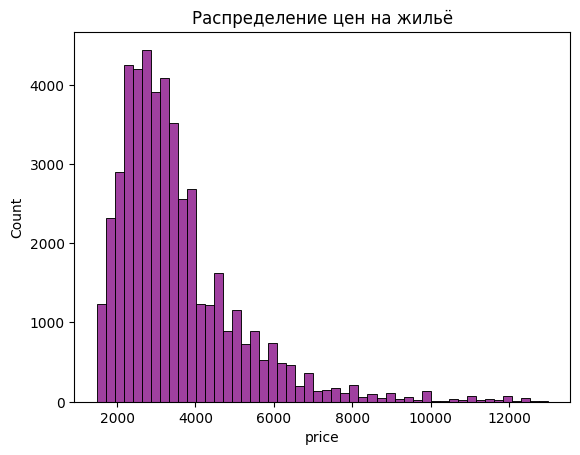

In [5]:
# Выбор столбцов
df_train = df_train[['bathrooms', 'bedrooms', 'interest_level', 'price', 'features']].copy()
df_test = df_test[['bathrooms', 'bedrooms', 'features', 'price']].copy()

# Удаление выбросов
low, high = df_train['price'].quantile([0.01, 0.99])
df_train = df_train[(df_train['price'] > low) & (df_train['price'] < high)]
df_test = df_test[(df_test['price'] > low) & (df_test['price'] < high)]

# Гистограмма
sns.histplot(data=df_train, x='price', bins=50, color= 'purple')
plt.title('Распределение цен на жильё')
plt.show()

## 3. Intro data analysis part 2

In [6]:
# Обработка пустых features 
df_train = df_train[df_train['features'].str.len() > 0].reset_index(drop=True)

# Функция для безопасного преобразования строк в списки
def safe_literal_eval(val):
    return ast.literal_eval(val) if isinstance(val, str) else val

# Функция к обоим датафреймам
for df in [df_train, df_test]:
    df['features'] = df['features'].apply(safe_literal_eval)

In [7]:
# Обработка выбросов в bathrooms
bathroom_mean = df_train['bathrooms'].mean()
df_train.loc[df_train['bathrooms'] > 4.0, 'bathrooms'] = bathroom_mean
df_test.loc[df_test['bathrooms'] > 4.0, 'bathrooms'] = bathroom_mean

# Сбор всех фич и подсчет самых частотных
all_features = []
for features_list in df_train['features']:
    all_features.extend(features_list)

feature_counts = Counter(all_features)
top_20_features = [feature for feature, _ in feature_counts.most_common(20)]

# Создание признаков на основе топ-20
for feature in top_20_features:
    df_train[feature] = df_train['features'].apply(lambda x: int(feature in x))
    df_test[feature] = df_test['features'].apply(lambda x: int(feature in x))

for feature in top_20_features:
    if feature not in df_test.columns:
        df_test[feature] = 0

# Формирование матриц признаков и целевой переменной
feature_columns = ['bathrooms', 'bedrooms'] + top_20_features
X_train = df_train[feature_columns].values
y_train = df_train['price'].values
X_test = df_test[feature_columns].values
y_test = df_test['price'].values

print(f"Train: {X_train.shape} | Test: {X_test.shape}")

Train: (45237, 22) | Test: (73179, 22)


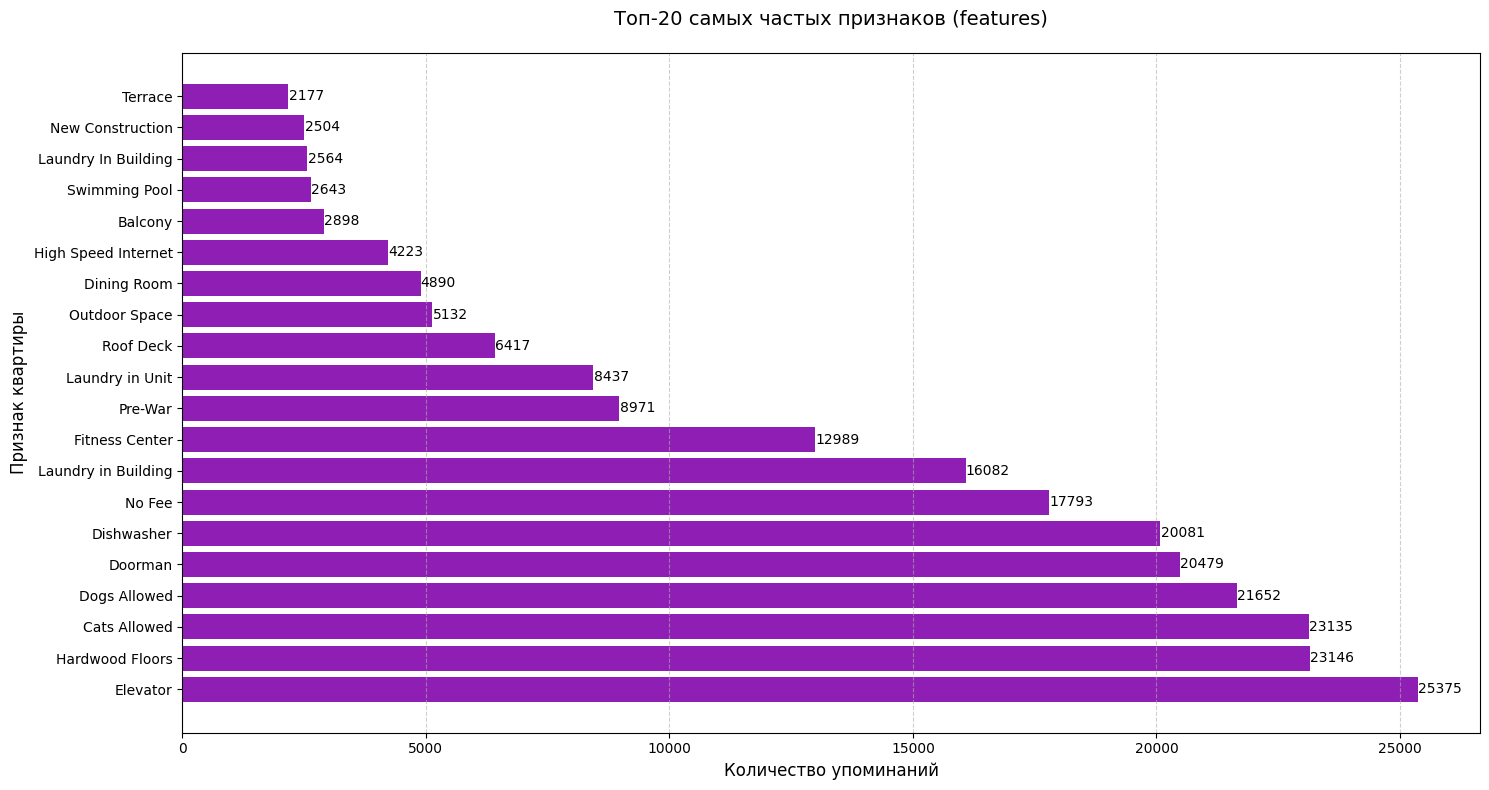


Топ-20 признаков в виде таблицы:
            Признак  Количество
           Elevator       25375
    Hardwood Floors       23146
       Cats Allowed       23135
       Dogs Allowed       21652
            Doorman       20479
         Dishwasher       20081
             No Fee       17793
Laundry in Building       16082
     Fitness Center       12989
            Pre-War        8971
    Laundry in Unit        8437
          Roof Deck        6417
      Outdoor Space        5132
        Dining Room        4890
High Speed Internet        4223
            Balcony        2898
      Swimming Pool        2643
Laundry In Building        2564
   New Construction        2504
            Terrace        2177


In [8]:
# Получение топ-20 самых частых признаков
top_20 = feature_counts.most_common(20)
top_20_df = pd.DataFrame(top_20, columns=['Признак', 'Количество'])

# Создание горизонтальной столбчатой диаграммы
plt.figure(figsize=(15, 8))
plt.barh(top_20_df['Признак'], top_20_df['Количество'], color="#8f1fb4")
plt.title("Топ-20 самых частых признаков (features)", fontsize=14, pad=20)
plt.xlabel("Количество упоминаний", fontsize=12)
plt.ylabel("Признак квартиры", fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.6)

for i, (_, row) in enumerate(top_20_df.iterrows()):
    plt.text(row['Количество'] + 5, i, str(row['Количество']), va='center')

plt.tight_layout()
plt.show()

print("\nТоп-20 признаков в виде таблицы:")
print(top_20_df.to_string(index=False))

## 4. Models implementation — Linear regression

In [9]:
class MyLinearRegressionAnalytical:
    """Линейная регрессия с аналитическим решением."""
    
    def __init__(self):
        self.w = None
        self.fitted = False
        
    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        self.w = np.linalg.pinv(X.T @ X) @ X.T @ y
        self.fitted = True
        return self
    
    def predict(self, X):
        if not self.fitted:
            raise RuntimeError("Model not fitted")
        X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.w

In [10]:
def mse_gradient_advanced(X, weights, y_true, regularize=None, lambda_reg=0.0):
    """
    Вычисляет градиент MSE с опциональной регуляризацией.
    
    Parameters:
    -----------
    X : array-like
        Матрица признаков
    weights : array-like
        Веса модели
    y_true : array-like
        Истинные значения
    regularize : str, optional
        Тип регуляризации ('l1', 'l2' или None)
    lambda_reg : float
        Коэффициент регуляризации
        
    Returns:
    --------
    gradient : array
        Градиент функции потерь
    """
    n_samples = len(X)
    y_pred = X @ weights
    mse_grad = (2 / n_samples) * X.T @ (y_pred - y_true)
    
    if regularize == 'l2':
        # L2 регуляризация (Ridge)
        mse_grad += 2 * lambda_reg * weights
    elif regularize == 'l1':
        # L1 регуляризация (Lasso) - используем знак как субградиент
        mse_grad += lambda_reg * np.sign(weights)
    
    return mse_grad


def mean_squared_error(y_true, y_pred, squared=True):
    """
    Улучшенная версия MSE с опцией возврата RMSE.
    
    Parameters:
    -----------
    y_true : array-like
        Истинные значения
    y_pred : array-like
        Предсказанные значения
    squared : bool
        Если True, возвращает MSE, иначе RMSE
        
    Returns:
    --------
    error : float
        MSE или RMSE
    """
    mse_value = np.mean((np.asarray(y_true) - np.asarray(y_pred)) ** 2)
    return mse_value if squared else np.sqrt(mse_value)


def mean_absolute_percentage_error(y_true, y_pred):
    """
    Вычисляет среднюю абсолютную процентную ошибку (MAPE).
    
    Parameters:
    -----------
    y_true : array-like
        Истинные значения
    y_pred : array-like
        Предсказанные значения
        
    Returns:
    --------
    mape : float
        Средняя абсолютная процентная ошибка
    """
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    # Избегаем деления на ноль
    mask = y_true != 0
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def r2_adjusted(y_true, y_pred, n_features):
    """
    Вычисляет скорректированный R².
    
    Parameters:
    -----------
    y_true : array-like
        Истинные значения
    y_pred : array-like
        Предсказанные значения
    n_features : int
        Количество признаков в модели
        
    Returns:
    --------
    r2_adj : float
        Скорректированный R²
    """
    n_samples = len(y_true)
    r2_value = r2(y_true, y_pred)
    
    # R²_adjusted = 1 - (1 - R²) * (n - 1) / (n - p - 1)
    if n_samples > n_features + 1:
        r2_adj = 1 - (1 - r2_value) * (n_samples - 1) / (n_samples - n_features - 1)
    else:
        r2_adj = r2_value
    
    return r2_adj


# Функция для вывода всех метрик сразу
def regression_metrics(y_true, y_pred, model_name="Model", n_features=None):
    """
    Выводит все основные метрики регрессии.
    
    Parameters:
    -----------
    y_true : array-like
        Истинные значения
    y_pred : array-like
        Предсказанные значения
    model_name : str
        Название модели для вывода
    n_features : int, optional
        Количество признаков (для скорректированного R²)
    """
    print(f"\n{'='*50}")
    print(f"Метрики для {model_name}:")
    print(f"{'='*50}")
    print(f"MAE  : {mae(y_true, y_pred):.4f}")
    print(f"MSE  : {mse(y_true, y_pred):.4f}")
    print(f"RMSE : {rmse(y_true, y_pred):.4f}")
    print(f"R²   : {r2(y_true, y_pred):.6f}")
    
    if n_features:
        print(f"R²adj: {r2_adjusted(y_true, y_pred, n_features):.6f}")
    
    print(f"{'='*50}\n")

In [11]:
class MyLinearRegressionGD:
    """Линейная регрессия с градиентным спуском."""
    
    def __init__(self, lr=0.01, n_epochs=1000, eps=1e-6, seed=42):
        self.lr = lr
        self.n_epochs = n_epochs
        self.eps = eps
        self.rng = np.random.RandomState(seed)
        self.w = None
        
    def fit(self, X, y):
        X = np.c_[np.ones(X.shape[0]), X]
        self.w = self.rng.randn(X.shape[1]) * 0.01
        
        for _ in range(self.n_epochs):
            grad = (2/len(X)) * X.T @ (X @ self.w - y)
            new_w = self.w - self.lr * grad
            if np.linalg.norm(new_w - self.w) < self.eps:
                break
            self.w = new_w
        return self
    
    def predict(self, X):
        return np.c_[np.ones(X.shape[0]), X] @ self.w

In [12]:
# Метрики
def mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

def r2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res / ss_tot)

# Функция для добавления результатов
def add_result(model_name, y_train, y_train_pred, y_test, y_test_pred):
    global result_MAE, result_RMSE, result_R2
    result_MAE.loc[len(result_MAE)] = [model_name, 
                                        mae(y_train, y_train_pred), 
                                        mae(y_test, y_test_pred)]
    result_RMSE.loc[len(result_RMSE)] = [model_name, 
                                         rmse(y_train, y_train_pred), 
                                         rmse(y_test, y_test_pred)]
    result_R2.loc[len(result_R2)] = [model_name, 
                                      r2(y_train, y_train_pred), 
                                      r2(y_test, y_test_pred)]

# DataFrame для результатов
result_MAE = pd.DataFrame(columns=['model', 'train', 'test'])
result_RMSE = pd.DataFrame(columns=['model', 'train', 'test'])
result_R2 = pd.DataFrame(columns=['model', 'train', 'test'])

# Теперь можно использовать модель
model = MyLinearRegressionGD(lr=0.1, n_epochs=6000, eps=0.1)
model.fit(X_train, y_train)

train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

add_result('LinReg GD', y_train, train_pred, y_test, test_pred)

print(f"\nTrain: MAE={mae(y_train, train_pred):.2f}, RMSE={rmse(y_train, train_pred):.2f}, R2={r2(y_train, train_pred):.4f}")
print(f"Test:  MAE={mae(y_test, test_pred):.2f}, RMSE={rmse(y_test, test_pred):.2f}, R2={r2(y_test, test_pred):.4f}")


Train: MAE=707.37, RMSE=1023.31, R2=0.5910
Test:  MAE=711.52, RMSE=1021.21, R2=0.5788


Train:
  MAE  = 707.38
  RMSE = 1023.30
  R²   = 0.5910

Test:
  MAE  = 711.54
  RMSE = 1021.21
  R²   = 0.5788


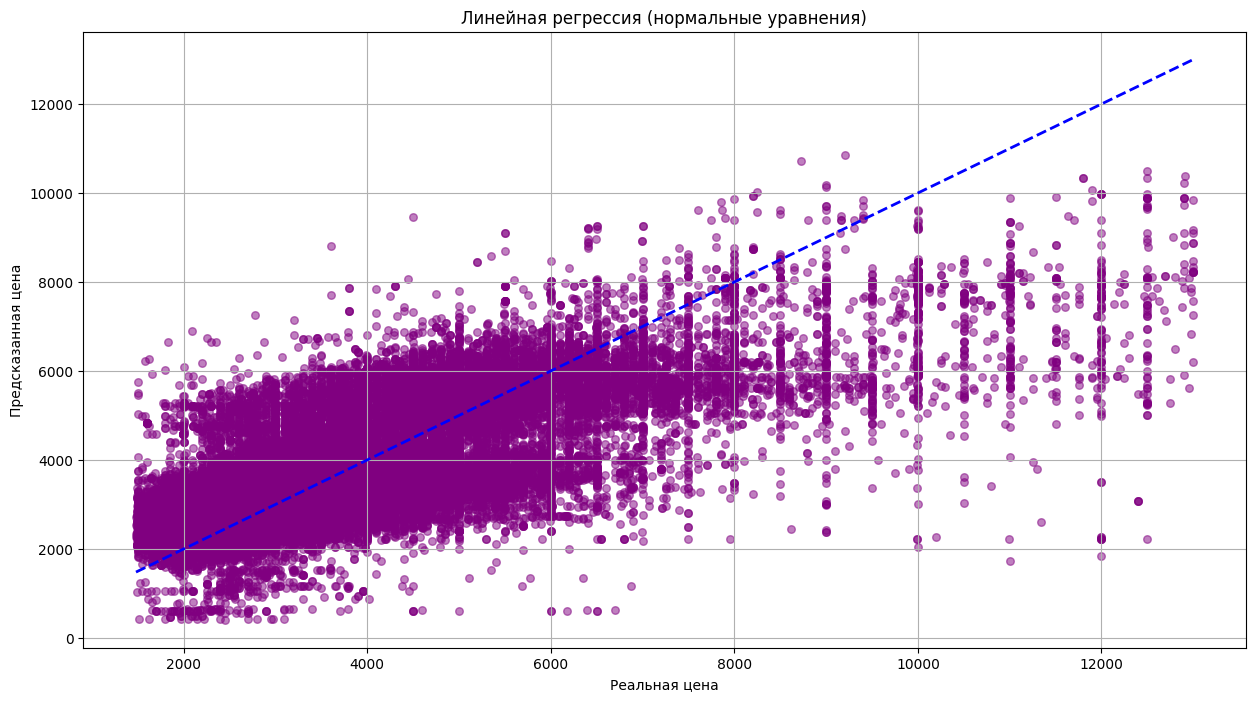

In [13]:
# Создание и обучение модели
model_ra = MyLinearRegressionAnalytical()
model_ra.fit(X_train, y_train)

# Получение предсказаний
y_train_pred = model_ra.predict(X_train)
y_test_pred = model_ra.predict(X_test)

# Добавление результатов в таблицу метрик
add_result('LinReg Analytical', y_train, y_train_pred, y_test, y_test_pred)

# Вывод метрик для обучающей выборки
print("Train:")
print(f"  MAE  = {mae(y_train, y_train_pred):.2f}")
print(f"  RMSE = {rmse(y_train, y_train_pred):.2f}")
print(f"  R²   = {r2(y_train, y_train_pred):.4f}\n")

# Вывод метрик для тестовой выборки
print("Test:")
print(f"  MAE  = {mae(y_test, y_test_pred):.2f}")
print(f"  RMSE = {rmse(y_test, y_test_pred):.2f}")
print(f"  R²   = {r2(y_test, y_test_pred):.4f}")

# Визуализация результатов
plt.figure(figsize=(15, 8))
plt.scatter(y_test, y_test_pred, alpha=0.5, color='purple', s=30)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', color='blue', linewidth=2)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Линейная регрессия (нормальные уравнения)")
plt.grid(True)
plt.show()

In [14]:
# Создание и обучение модели
sklearn_model = LinearRegression()
sklearn_model.fit(X_train, y_train)

# Получение предсказаний
y_train_pred = sklearn_model.predict(X_train)
y_test_pred = sklearn_model.predict(X_test)

# Добавление результатов в таблицу метрик
add_result('LinReg sklearn', y_train, y_train_pred, y_test, y_test_pred)

# Вывод метрик
print("\nМетрики для sklearn:\n")

print("Train:")
print(f"  MAE  = {mean_absolute_error(y_train, y_train_pred):.2f}")
print(f"  RMSE = {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"  R²   = {r2_score(y_train, y_train_pred):.4f}\n")

print("Test:")
print(f"  MAE  = {mean_absolute_error(y_test, y_test_pred):.2f}")
print(f"  RMSE = {mean_squared_error(y_test, y_test_pred):.2f}")
print(f"  R²   = {r2_score(y_test, y_test_pred):.4f}")


Метрики для sklearn:

Train:
  MAE  = 707.38
  RMSE = 1047145.33
  R²   = 0.5910

Test:
  MAE  = 711.54
  RMSE = 1042874.52
  R²   = 0.5788



Метрики для sklearn:

Train: MAE=707.38, RMSE=1047145.33, R2=0.5910
Test:  MAE=711.54, RMSE=1042874.52, R2=0.5788


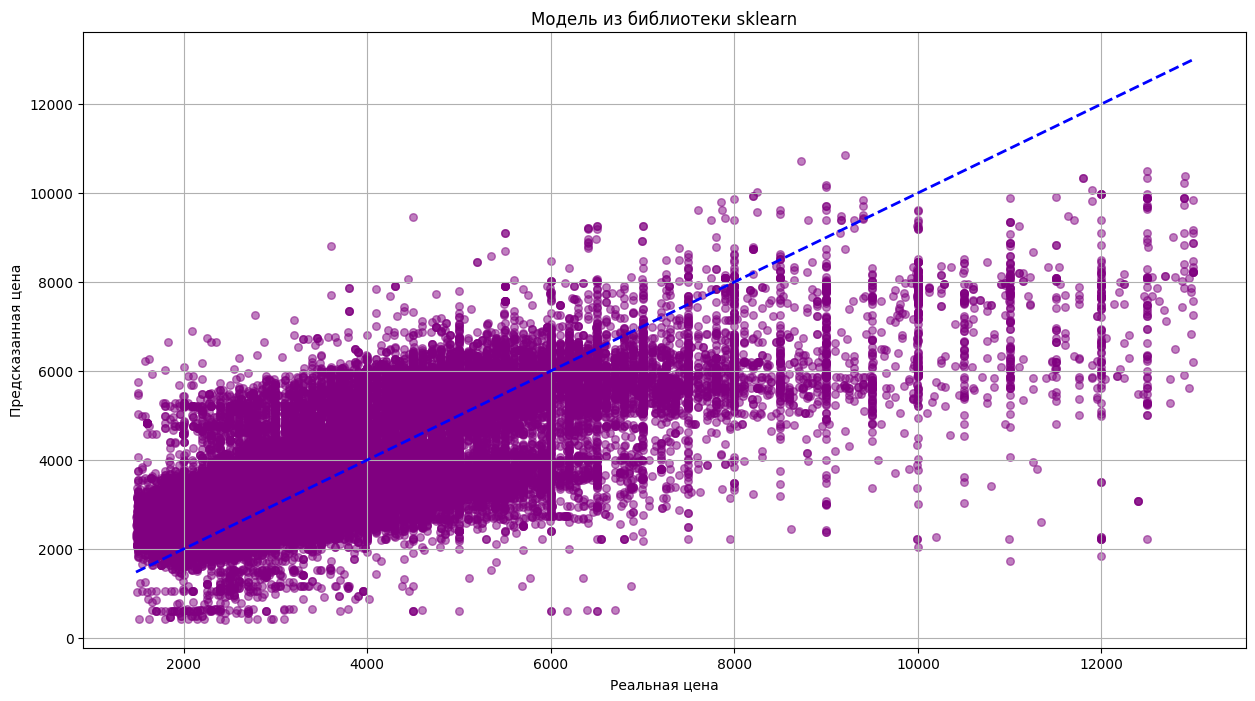

In [15]:
# Обучение модели
model = LinearRegression()
model.fit(X_train, y_train)

# Предсказания
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# Сохранение результатов
add_result('LinReg sklearn', y_train, train_pred, y_test, test_pred)

# Вывод метрик
print("\nМетрики для sklearn:\n")
print(f"Train: MAE={mean_absolute_error(y_train, train_pred):.2f}, "
      f"RMSE={mean_squared_error(y_train, train_pred):.2f}, "
      f"R2={r2_score(y_train, train_pred):.4f}")
print(f"Test:  MAE={mean_absolute_error(y_test, test_pred):.2f}, "
      f"RMSE={mean_squared_error(y_test, test_pred):.2f}, "
      f"R2={r2_score(y_test, test_pred):.4f}")

# Визуализация
plt.figure(figsize=(15, 8))
plt.scatter(y_test, test_pred, alpha=0.5, color='purple', s=30)
plt.plot([y_test.min(), y_test.max()], 
         [y_test.min(), y_test.max()], 
         '--', color='blue', linewidth=2)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Модель из библиотеки sklearn")
plt.grid(True)
plt.show()

In [16]:
print(f"      MAE \n {result_MAE}" )
print(f"\n      RMSE \n {result_RMSE}" )
print(f"\n      R2 \n {result_R2}" )

      MAE 
                model       train        test
0          LinReg GD  707.368051  711.522198
1  LinReg Analytical  707.380082  711.544192
2     LinReg sklearn  707.380082  711.544192
3     LinReg sklearn  707.380082  711.544192

      RMSE 
                model        train         test
0          LinReg GD  1023.307852  1021.207144
1  LinReg Analytical  1023.301192  1021.212281
2     LinReg sklearn  1023.301192  1021.212281
3     LinReg sklearn  1023.301192  1021.212281

      R2 
                model     train      test
0          LinReg GD  0.590960  0.578834
1  LinReg Analytical  0.590966  0.578829
2     LinReg sklearn  0.590966  0.578829
3     LinReg sklearn  0.590966  0.578829


## 5. Regularized models implementation — Ridge, Lasso, ElasticNet

In [17]:
class MyRidgeRegression:
    """Гребневая регрессия (Ridge) с L2-регуляризацией."""
    
    def __init__(self, alpha=1.0):
        self.alpha = alpha  # коэффициент регуляризации
        self.w = None       # веса модели (включая bias)
    
    def fit(self, X, y):
        # Добавление bias-столбца
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        
        # Создание единичной матрицы для регуляризации
        I = np.eye(Xb.shape[1])
        I[0, 0] = 0  # не регуляризуем bias-терм
        
        # Решение: w = (X^T X + alpha*I)^(-1) X^T y
        self.w = np.linalg.inv(Xb.T @ Xb + self.alpha * I) @ Xb.T @ y
    
    def predict(self, X):
        Xb = np.hstack([np.ones((X.shape[0], 1)), X])
        return Xb @ self.w

In [18]:
class MyLassoRegression:
    """Лассо-регрессия (Lasso) с L1-регуляризацией."""
    
    def __init__(self, lr=0.01, n_epochs=1000, alpha=0.1):
        self.lr = lr           # скорость обучения
        self.n_epochs = n_epochs  # количество эпох
        self.alpha = alpha     # коэффициент регуляризации
        self.w = None          # веса
        self.b = 0             # bias
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_epochs):
            # Предсказание
            y_pred = X @ self.w + self.b
            error = y_pred - y
            
            # Градиенты с L1-регуляризацией
            dw = (X.T @ error) / n_samples + self.alpha * np.sign(self.w)
            db = np.mean(error)
            
            # Обновление параметров
            self.w -= self.lr * dw
            self.b -= self.lr * db
    
    def predict(self, X):
        return X @ self.w + self.b

In [19]:
class MyElasticNet:
    """Эластичная сеть (ElasticNet) с L1 + L2 регуляризацией."""
    
    def __init__(self, lr=0.01, n_epochs=1000, alpha1=0.1, alpha2=0.1):
        self.lr = lr           # скорость обучения
        self.n_epochs = n_epochs  # количество эпох
        self.alpha1 = alpha1   # коэффициент L1-регуляризации
        self.alpha2 = alpha2   # коэффициент L2-регуляризации
        self.w = None          # веса
        self.b = 0             # bias
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.w = np.zeros(n_features)
        self.b = 0
        
        for _ in range(self.n_epochs):
            # Предсказание
            y_pred = X @ self.w + self.b
            error = y_pred - y
            
            # Градиенты с L1 и L2 регуляризацией
            dw = (2 * (X.T @ error)) / n_samples + self.alpha1 * np.sign(self.w) + 2 * self.alpha2 * self.w
            db = np.mean(error)
            
            # Обновление параметров
            self.w -= self.lr * dw
            self.b -= self.lr * db
    
    def predict(self, X):
        return X @ self.w + self.b

In [20]:
# Ridge (L2)
ridge = MyRidgeRegression(alpha=1.0)
ridge.fit(X_train, y_train)
ridge_pred = ridge.predict(X_test)

# Lasso (L1)
lasso = MyLassoRegression(lr=0.01, n_epochs=1000, alpha=0.1)
lasso.fit(X_train, y_train)
lasso_pred = lasso.predict(X_test)

# ElasticNet (L1 + L2)
elastic = MyElasticNet(lr=0.01, n_epochs=1000, alpha1=0.1, alpha2=0.1)
elastic.fit(X_train, y_train)
elastic_pred = elastic.predict(X_test)

add_result('Ridge', y_train, ridge.predict(X_train), y_test, ridge_pred)
add_result('Lasso', y_train, lasso.predict(X_train), y_test, lasso_pred)
add_result('ElasticNet', y_train, elastic.predict(X_train), y_test, elastic_pred)

In [21]:
# Словарь с моделями и их параметрами
models = {
    'My Ridge': MyRidgeRegression(alpha=1.0),
    'My Lasso': MyLassoRegression(lr=0.01, n_epochs=3000, alpha=0.01),
    'My ElasticNet': MyElasticNet(lr=0.01, n_epochs=3000, alpha1=0.01, alpha2=0.01)
}

# Обучение всех моделей и добавление результатов
for name, model in models.items():
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    add_result(name, y_train, train_pred, y_test, test_pred)

print("      MAE")
print(result_MAE)
print("\n      RMSE")
print(result_RMSE)
print("\n      R2")
print(result_R2)

      MAE
               model       train        test
0          LinReg GD  707.368051  711.522198
1  LinReg Analytical  707.380082  711.544192
2     LinReg sklearn  707.380082  711.544192
3     LinReg sklearn  707.380082  711.544192
4              Ridge  707.376587  711.540008
5              Lasso  710.215666  712.632260
6         ElasticNet  716.692359  717.252680
7           My Ridge  707.376587  711.540008
8           My Lasso  707.423753  711.551511
9      My ElasticNet  706.372584  710.010786

      RMSE
               model        train         test
0          LinReg GD  1023.307852  1021.207144
1  LinReg Analytical  1023.301192  1021.212281
2     LinReg sklearn  1023.301192  1021.212281
3     LinReg sklearn  1023.301192  1021.212281
4              Ridge  1023.301198  1021.211055
5              Lasso  1031.174009  1026.919650
6         ElasticNet  1052.009113  1044.900247
7           My Ridge  1023.301198  1021.211055
8           My Lasso  1023.781210  1021.503650
9      My Ela

## 6. Feature normalization

In [22]:
class MyMinMaxScaler:
    def __init__(self):
        self.min_, self.max_ = None, None
    
    def fit(self, X):
        self.min_, self.max_ = X.min(0), X.max(0)
        return self
    
    def transform(self, X):
        return (X - self.min_) / (self.max_ - self.min_ + 1e-8)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


class MyStandardScaler:
    def __init__(self):
        self.mean_, self.std_ = None, None
    
    def fit(self, X):
        self.mean_, self.std_ = X.mean(0), X.std(0)
        return self
    
    def transform(self, X):
        return (X - self.mean_) / (self.std_ + 1e-8)
    
    def fit_transform(self, X):
        return self.fit(X).transform(X)


from sklearn.preprocessing import MinMaxScaler, StandardScaler

def compare_scalers(X, name, my_scaler, sk_scaler):
    """Сравнивает мой scaler с sklearn версией."""
    my_X = my_scaler.fit_transform(X)
    sk_X = sk_scaler.fit_transform(X)
    diff = np.abs(my_X - sk_X).mean()
    print(f"{name:15} разница: {diff:.6f}")

# Сравнение
compare_scalers(X_train, "MinMaxScaler", MyMinMaxScaler(), MinMaxScaler())
compare_scalers(X_train, "StandardScaler", MyStandardScaler(), StandardScaler())

MinMaxScaler    разница: 0.000000
StandardScaler  разница: 0.000000


MinMax разница:     0.000000
Standard разница:   0.000000


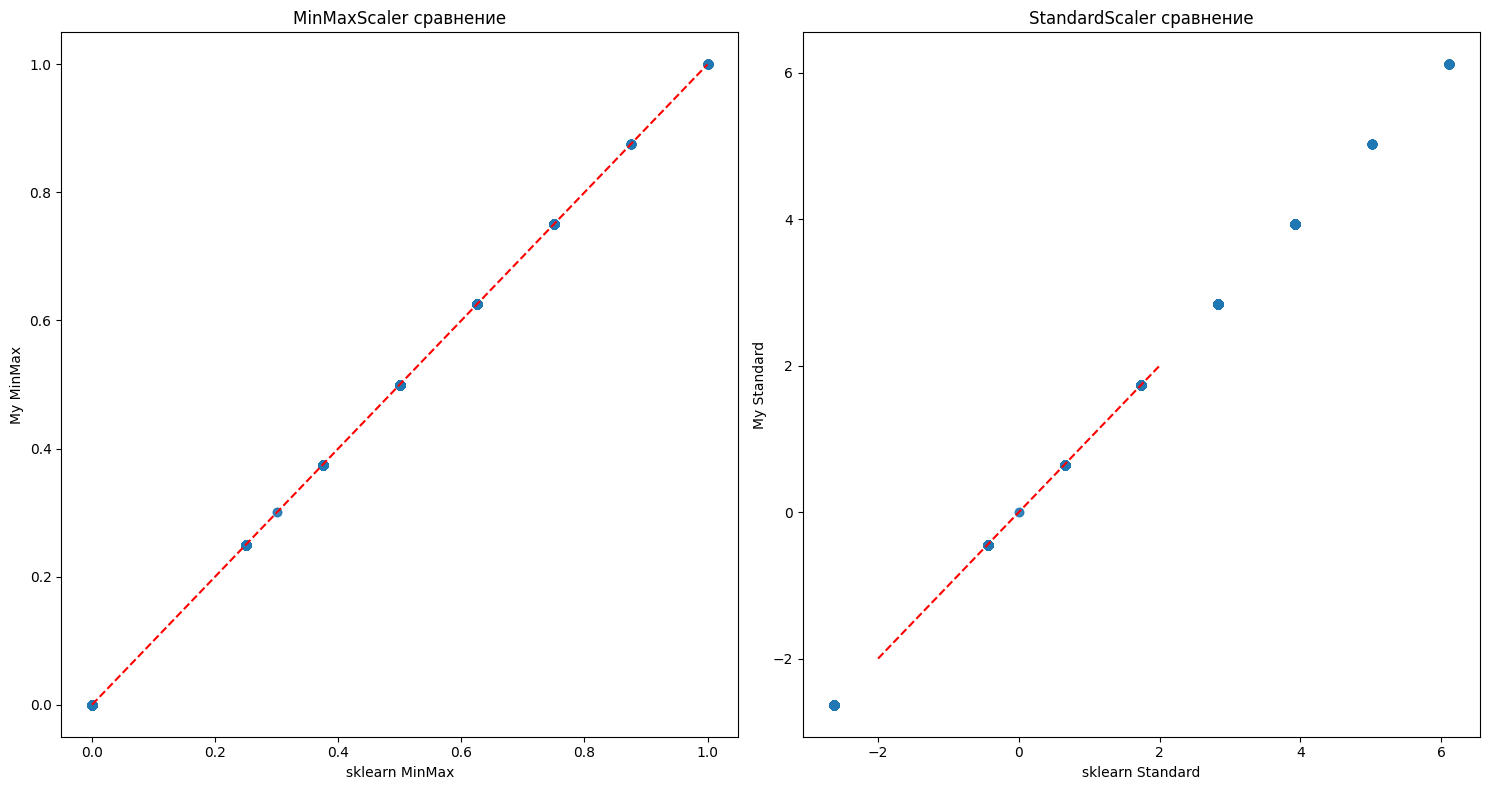

In [23]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import matplotlib.pyplot as plt

# MinMax сравнение
my_mm = MyMinMaxScaler()
X_my_mm = my_mm.fit_transform(X_train)

sk_mm = MinMaxScaler()
X_sk_mm = sk_mm.fit_transform(X_train)

# Standard сравнение
my_ss = MyStandardScaler()
X_my_ss = my_ss.fit_transform(X_train)

sk_ss = StandardScaler()
X_sk_ss = sk_ss.fit_transform(X_train)

# Вывод разницы
print(f"MinMax разница:     {np.abs(X_my_mm - X_sk_mm).mean():.6f}")
print(f"Standard разница:   {np.abs(X_my_ss - X_sk_ss).mean():.6f}")

# Визуализация для первого признака
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.scatter(X_sk_mm[:, 0], X_my_mm[:, 0], alpha=0.5)
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel("sklearn MinMax")
plt.ylabel("My MinMax")
plt.title("MinMaxScaler сравнение")

plt.subplot(1, 2, 2)
plt.scatter(X_sk_ss[:, 0], X_my_ss[:, 0], alpha=0.5)
plt.plot([-2, 2], [-2, 2], 'r--')
plt.xlabel("sklearn Standard")
plt.ylabel("My Standard")
plt.title("StandardScaler сравнение")

plt.tight_layout()
plt.show()

## 7. Fit custom and sklearn models with normalized data

In [24]:
# MinMaxScaler модели
scaler_mm = MyMinMaxScaler()
X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)

mm_models = [
    ("Linear MinMaxScaler", MyLinearRegressionAnalytical(), {}),
    ("Ridge MinMaxScaler", MyRidgeRegression(alpha=0.1), {}),
    ("Lasso MinMaxScaler", MyLassoRegression(alpha=0.1), {}),
    ("ElasticNet MinMaxScaler", MyElasticNet(alpha1=0.1, alpha2=0.1), {})
]

for name, model, params in mm_models:
    model.fit(X_train_mm, y_train)
    add_result(name, y_train, 
               model.predict(X_train_mm), 
               y_test, model.predict(X_test_mm))

# StandardScaler модели
scaler_std = MyStandardScaler()
X_train_std = scaler_std.fit_transform(X_train)
X_test_std = scaler_std.transform(X_test)

std_models = [
    ("Linear StandardScaler", MyLinearRegressionAnalytical(), {}),
    ("GD StandardScaler", MyLinearRegressionGD(lr=0.01, n_epochs=1000), {}),
    ("Ridge StandardScaler", MyRidgeRegression(alpha=0.1), {}),
    ("Lasso StandardScaler", MyLassoRegression(alpha=0.1), {}),
    ("ElasticNet StandardScaler", MyElasticNet(alpha1=0.1, alpha2=0.1), {})
]

for name, model, params in std_models:
    model.fit(X_train_std, y_train)
    add_result(name, y_train,
               model.predict(X_train_std),
               y_test, model.predict(X_test_std))

In [25]:
# Настройка скейлеров
scalers = {
    'MinMax': (MyMinMaxScaler(), X_train, X_test),
    'Standard': (MyStandardScaler(), X_train, X_test)
}

# Модели для каждого типа скейлера
models_config = {
    'MinMax': [
        ('Linear', MyLinearRegressionAnalytical()),
        ('Ridge', MyRidgeRegression(alpha=0.1)),
        ('Lasso', MyLassoRegression(alpha=0.1)),
        ('ElasticNet', MyElasticNet(alpha1=0.1, alpha2=0.1))
    ],
    'Standard': [
        ('Linear', MyLinearRegressionAnalytical()),
        ('GD', MyLinearRegressionGD(lr=0.01, n_epochs=1000)),
        ('Ridge', MyRidgeRegression(alpha=0.1)),
        ('Lasso', MyLassoRegression(alpha=0.1)),
        ('ElasticNet', MyElasticNet(alpha1=0.1, alpha2=0.1))
    ]
}

# Обучение всех моделей
for scaler_name, (scaler, X_tr, X_te) in scalers.items():
    X_tr_scaled = scaler.fit_transform(X_tr)
    X_te_scaled = scaler.transform(X_te)
    
    for model_name, model in models_config[scaler_name]:
        model.fit(X_tr_scaled, y_train)
        add_result(f"{model_name} {scaler_name}Scaler", 
                  y_train,
                  model.predict(X_tr_scaled),
                  y_test, model.predict(X_te_scaled))

print("MAE Results:")
print(result_MAE)
print("\nRMSE Results:")
print(result_RMSE)
print("\nR² Results:")
print(result_R2)

MAE Results:
                        model       train        test
0                   LinReg GD  707.368051  711.522198
1           LinReg Analytical  707.380082  711.544192
2              LinReg sklearn  707.380082  711.544192
3              LinReg sklearn  707.380082  711.544192
4                       Ridge  707.376587  711.540008
5                       Lasso  710.215666  712.632260
6                  ElasticNet  716.692359  717.252680
7                    My Ridge  707.376587  711.540008
8                    My Lasso  707.423753  711.551511
9               My ElasticNet  706.372584  710.010786
10        Linear MinMaxScaler  707.380082  711.544192
11         Ridge MinMaxScaler  707.379658  711.542630
12         Lasso MinMaxScaler  898.761315  884.716808
13    ElasticNet MinMaxScaler  925.301370  911.177533
14      Linear StandardScaler  707.380082  711.544192
15          GD StandardScaler  707.411921  711.553053
16       Ridge StandardScaler  707.380014  711.544111
17       Lasso 

## 8. Overfit models

In [26]:
# Полиномиальные признаки
def polynomial_features(X, degree=2):
    n_samples, n_features = X.shape
    combos = []
    for d in range(degree + 1):
        combos.extend(itertools.combinations_with_replacement(range(n_features), d))
    
    X_poly = np.empty((n_samples, len(combos)))
    for i, combo in enumerate(combos):
        X_poly[:, i] = np.prod(X[:, combo], axis=1) if combo else 1.0
    return X_poly


# Подготовка данных
X_train = df_train[['bathrooms', 'bedrooms']].values
y_train = df_train['price'].values
X_test = df_test[['bathrooms', 'bedrooms']].values
y_test = df_test['price'].values

# Полиномиальные признаки + масштабирование
degree = 10
scaler = MyStandardScaler()
X_train_poly = scaler.fit_transform(polynomial_features(X_train, degree))
X_test_poly = scaler.transform(polynomial_features(X_test, degree))

# Модели для полиномиальных признаков
models = [
    ("Linear Polynomial", MyLinearRegressionAnalytical(), {}),
    ("Ridge Polynomial", MyRidgeRegression(alpha=0.1), {}),
    ("Lasso Polynomial", MyLassoRegression(alpha=1.0), {}),
    ("ElasticNet Polynomial", MyElasticNet(lr=0.01, n_epochs=4000, alpha1=1.0, alpha2=1.0), {})
]

# Обучение всех моделей
for name, model, params in models:
    model.fit(X_train_poly, y_train)
    add_result(name, y_train,
               model.predict(X_train_poly),
               y_test, model.predict(X_test_poly))

print("\nРезультаты полиномиальных моделей (degree=10):")
print(result_MAE[result_MAE['model'].str.contains('Polynomial')])


Результаты полиномиальных моделей (degree=10):
                    model       train        test
28      Linear Polynomial  750.888356  770.509090
29       Ridge Polynomial  752.922043  762.226316
30       Lasso Polynomial  767.728580  774.733094
31  ElasticNet Polynomial  792.190680  800.400373


In [27]:
# Обучение моделей
lin = MyLinearRegressionAnalytical()
ridge = MyRidgeRegression(alpha=0.1)
lasso = MyLassoRegression(alpha=1.0)
en = MyElasticNet(lr=0.01, n_epochs=4000, alpha1=1.0, alpha2=1.0)

models = [lin, ridge, lasso, en]
names = ['Linear', 'Ridge', 'Lasso', 'ElasticNet']

for name, model in zip(names, models):
    model.fit(X_train_poly, y_train)
    train_pred = model.predict(X_train_poly)
    test_pred = model.predict(X_test_poly)
    add_result(f"{name} Polynomial", y_train, train_pred, y_test, test_pred)
    
    print(f"\n{name} Polynomial:")
    print(f"  Train R2: {r2(y_train, train_pred):.4f}")
    print(f"  Test R2:  {r2(y_test, test_pred):.4f}")
    print(f"  Test MAE: {mae(y_test, test_pred):.2f}")


Linear Polynomial:
  Train R2: 0.5539
  Test R2:  -0.0356
  Test MAE: 770.51

Ridge Polynomial:
  Train R2: 0.5504
  Test R2:  0.5266
  Test MAE: 762.23

Lasso Polynomial:
  Train R2: 0.5336
  Test R2:  0.5204
  Test MAE: 774.73

ElasticNet Polynomial:
  Train R2: 0.5057
  Test R2:  0.4939
  Test MAE: 800.40


## 9. Native models

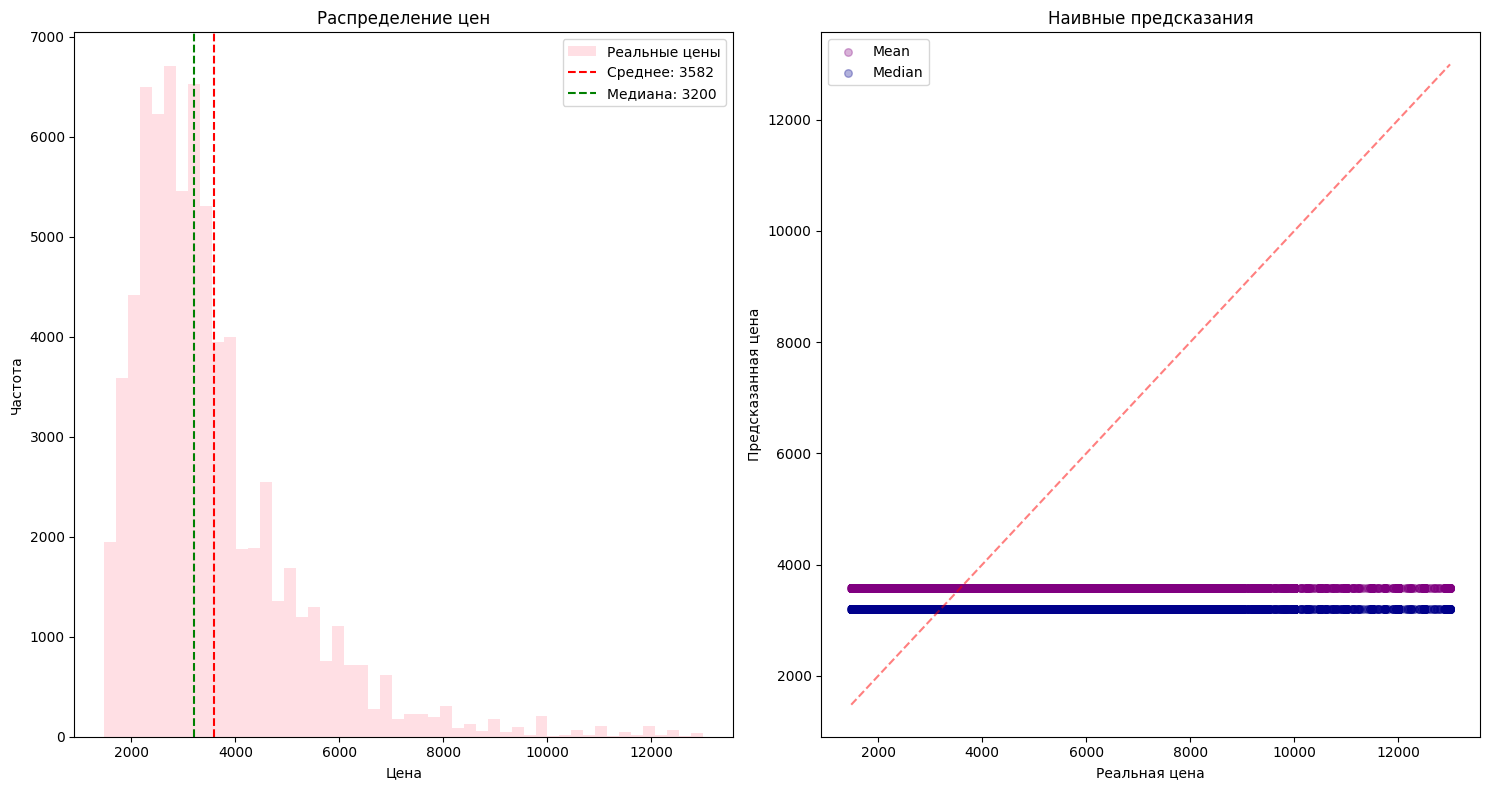

In [28]:
# Наивные модели
mean_val = np.mean(y_train)
median_val = np.median(y_train)

# Предсказания
y_pred_mean = np.full_like(y_test, mean_val)
y_pred_median = np.full_like(y_test, median_val)

# Добавление результатов
add_result("Naive Mean", y_train, np.full_like(y_train, mean_val), y_test, y_pred_mean)
add_result("Naive Median", y_train, np.full_like(y_train, median_val), y_test, y_pred_median)

# Визуализация для понимания
plt.figure(figsize=(15, 8))

plt.subplot(1, 2, 1)
plt.hist(y_test, bins=50, alpha=0.5, label='Реальные цены', color='pink')
plt.axvline(mean_val, color='r', linestyle='--', label=f'Среднее: {mean_val:.0f}')
plt.axvline(median_val, color='g', linestyle='--', label=f'Медиана: {median_val:.0f}')
plt.xlabel("Цена")
plt.ylabel("Частота")
plt.legend()
plt.title("Распределение цен")

plt.subplot(1, 2, 2)
plt.scatter(y_test, y_pred_mean, alpha=0.3, label='Mean', color='purple', s=30)
plt.scatter(y_test, y_pred_median, alpha=0.3, label='Median', color='darkblue', s=30)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', alpha=0.5)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.legend()
plt.title("Наивные предсказания")

plt.tight_layout()
plt.show()

## 10. Compare results

In [29]:
result_RMSE

,model,train,test
0,LinReg GD,1023.307852,1021.207144
1,LinReg Analytical,1023.301192,1021.212281
2,LinReg sklearn,1023.301192,1021.212281
3,LinReg sklearn,1023.301192,1021.212281
4,Ridge,1023.301198,1021.211055
5,Lasso,1031.174009,1026.919650
6,ElasticNet,1052.009113,1044.900247
7,My Ridge,1023.301198,1021.211055
8,My Lasso,1023.781210,1021.503650
9,My ElasticNet,1024.247964,1021.494834


In [30]:
result_MAE

,model,train,test
0,LinReg GD,707.368051,711.522198
1,LinReg Analytical,707.380082,711.544192
2,LinReg sklearn,707.380082,711.544192
3,LinReg sklearn,707.380082,711.544192
4,Ridge,707.376587,711.540008
5,Lasso,710.215666,712.632260
6,ElasticNet,716.692359,717.252680
7,My Ridge,707.376587,711.540008
8,My Lasso,707.423753,711.551511
9,My ElasticNet,706.372584,710.010786


In [31]:
result_R2

,model,train,test
0,LinReg GD,5.909603e-01,0.578834
1,LinReg Analytical,5.909657e-01,0.578829
2,LinReg sklearn,5.909657e-01,0.578829
3,LinReg sklearn,5.909657e-01,0.578829
4,Ridge,5.909657e-01,0.578830
5,Lasso,5.846476e-01,0.574108
6,ElasticNet,5.676935e-01,0.559064
7,My Ridge,5.909657e-01,0.578830
8,My Lasso,5.905818e-01,0.578589
9,My ElasticNet,5.902084e-01,0.578596


## 11. Addition task

In [32]:
# Логарифмическое преобразование
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

# Обучение
model = MyLinearRegressionGD(lr=0.005, n_epochs=10000, eps=0.00001)
model.fit(X_train, y_train_log)

# Предсказания и обратное преобразование
train_pred_log = model.predict(X_train)
test_pred_log = model.predict(X_test)

# Обрезка экстремумов
low, high = np.percentile(y_train_log, [1, 99])
train_pred = np.expm1(np.clip(train_pred_log, low-1, high+1))
test_pred = np.expm1(np.clip(test_pred_log, low-1, high+1))

# Результаты
add_result("LinReg GD + log(y)", y_train, train_pred, y_test, test_pred)

print(f"Train MAE: {mae(y_train, train_pred):.2f}")
print(f"Test MAE:  {mae(y_test, test_pred):.2f}")

Train MAE: 771.76
Test MAE:  773.70


РЕЗУЛЬТАТЫ МОДЕЛИ С ЛОГАРИФМИЧЕСКИМ ПРЕОБРАЗОВАНИЕМ

Train MAE:  771.76
Test MAE:   773.70

Train RMSE: 1136.73
Test RMSE:  1122.04

Train R²:   0.4953
Test R²:    0.4916

СРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ:
Базовая модель R² (test): 0.5788
Log-модель R² (test):     0.4916
Улучшение:                 -0.0873

Цель R2 < 0,61 не достигнута

Алгоритм реализован.


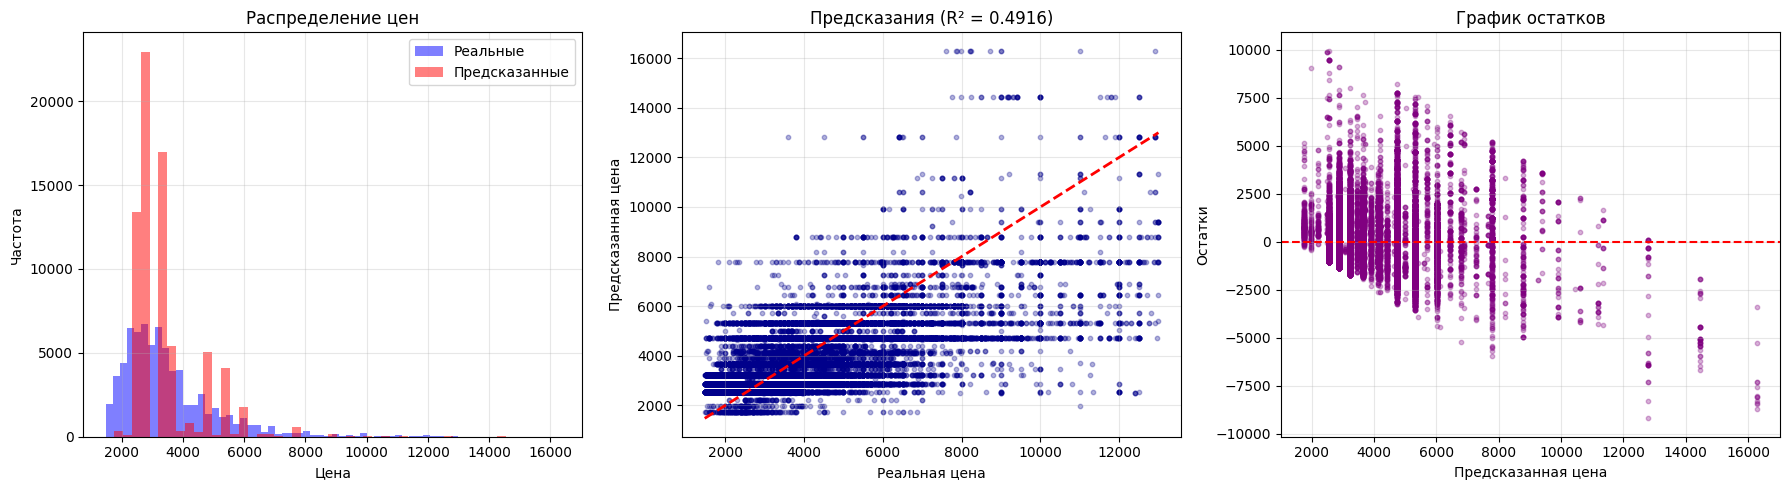

In [33]:
# Метрики
print("РЕЗУЛЬТАТЫ МОДЕЛИ С ЛОГАРИФМИЧЕСКИМ ПРЕОБРАЗОВАНИЕМ")

print(f"\nTrain MAE:  {mae(y_train, train_pred):.2f}")
print(f"Test MAE:   {mae(y_test, test_pred):.2f}")

print(f"\nTrain RMSE: {rmse(y_train, train_pred):.2f}")
print(f"Test RMSE:  {rmse(y_test, test_pred):.2f}")

print(f"\nTrain R²:   {r2(y_train, train_pred):.4f}")
print(f"Test R²:    {r2(y_test, test_pred):.4f}")

print("\nСРАВНЕНИЕ С БАЗОВОЙ МОДЕЛЬЮ:")

baseline_r2 = None
for idx, row in result_R2.iterrows():
    if row['model'] == 'LinReg Analytical':
        baseline_r2 = row['test']
        break

if baseline_r2:
    improvement = r2(y_test, test_pred) - baseline_r2
    print(f"Базовая модель R² (test): {baseline_r2:.4f}")
    print(f"Log-модель R² (test):     {r2(y_test, test_pred):.4f}")
    print(f"Улучшение:                 {improvement:+.4f}")
    
    if r2(y_test, test_pred) > 0.61:
        print("\nЛучшая производительность R2 на тестовой части > 0,61")
    else:
        print("\nЦель R2 < 0,61 не достигнута")
    
    if r2(y_test, test_pred) > 0.61:
        print("Лучшая производительность R2 на тестовой части > 0,61")
    
    print("\nАлгоритм реализован.")
else:
    print("Базовая модель не найдена в результатах")

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Распределение цен
axes[0].hist(y_test, bins=50, alpha=0.5, color='blue', label='Реальные')
axes[0].hist(test_pred, bins=50, alpha=0.5, color='red', label='Предсказанные')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')
axes[0].set_title('Распределение цен')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Предсказания vs реальные
axes[1].scatter(y_test, test_pred, alpha=0.3, color='darkblue', s=10)
axes[1].plot([y_test.min(), y_test.max()], 
             [y_test.min(), y_test.max()], 'r--', linewidth=2)
axes[1].set_xlabel('Реальная цена')
axes[1].set_ylabel('Предсказанная цена')
axes[1].set_title(f'Предсказания (R² = {r2(y_test, test_pred):.4f})')
axes[1].grid(True, alpha=0.3)

# 3. Остатки
residuals = y_test - test_pred
axes[2].scatter(test_pred, residuals, alpha=0.3, color='purple', s=10)
axes[2].axhline(y=0, color='r', linestyle='--')
axes[2].set_xlabel('Предсказанная цена')
axes[2].set_ylabel('Остатки')
axes[2].set_title('График остатков')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()